# Phase 3: the surrogate model

A fast machine learning model that predicts monthly tonnes directly from five operating settings, standing in for the twin itself. This is the phase that most directly echoes the PhD work behind this project: a fast learned stand in for a slow simulation is exactly what surrogate modelling is, just applied to an operational system here instead of a physical one.

The reasoning behind the five parameters, their ranges, the 90 day training horizon, and why a held out set matters more than cross validation alone is written up in `phase3_plan.md`.

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from twin.simulation import load_config, run_simulation
from twin.scenarios import run_scenario
from surrogate.sampling import (
    PARAM_RANGES,
    build_held_out_set,
    build_training_set,
    config_from_params,
)
from surrogate.train import (
    cross_validate,
    evaluate_on_held_out,
    train_gaussian_process,
    train_xgboost,
)

base_config = load_config(str(PROJECT_ROOT / "config.yaml"))
FEATURE_COLS = list(PARAM_RANGES.keys())

## The training and held out sets

Loads the cached 200 point training set and 30 point held out set built in step 4, or regenerates them if this is a fresh clone without `data/processed/` populated, since `data/` is gitignored and not shipped with the repo.

In [2]:
train_path = PROJECT_ROOT / "data" / "processed" / "surrogate_training_set.csv"
held_out_path = PROJECT_ROOT / "data" / "processed" / "surrogate_held_out_set.csv"

if train_path.exists():
    train_df = pd.read_csv(train_path)
else:
    train_df = build_training_set(base_config, save_path=str(train_path))

if held_out_path.exists():
    held_out_df = pd.read_csv(held_out_path)
else:
    held_out_df = build_held_out_set(base_config, save_path=str(held_out_path))

X_train, y_train = train_df[FEATURE_COLS], train_df["monthly_tonnes"]
X_held_out, y_held_out = held_out_df[FEATURE_COLS], held_out_df["monthly_tonnes"]

print(f"training set: {len(train_df)} points, held out set: {len(held_out_df)} points")
train_df.describe()

training set: 200 points, held out set: 30 points


,feed_rate_multiplier,skip_payload_tonnes,winder_speed_multiplier,breakdown_mtbf_hours,scheduled_downtime_hours_per_month,monthly_tonnes,winder_utilisation_pct
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.999989,11.998828,1.050052,250.036298,22.501167,215166.460410,85.316274
std,0.289497,2.314143,0.202537,86.782079,10.127276,53780.289818,16.150467
min,0.501270,8.038798,0.703325,101.028340,5.170656,128783.363478,42.219370
25%,0.750136,10.018177,0.877165,175.350504,13.809460,171397.858058,77.435410
50%,1.001164,11.994200,1.050763,250.433990,22.501937,207468.681850,93.926035
75%,1.247448,13.999866,1.224531,324.312595,31.225696,248024.896954,95.822958
max,1.498626,15.969543,1.396671,399.371091,39.891168,405553.092081,98.549854


## Training both models

XGBoost, the baseline, and a Gaussian process, the classical surrogate approach, both mapping the same five inputs to mean monthly tonnes.

In [3]:
xgb_model = train_xgboost(X_train, y_train)
gp_model = train_gaussian_process(X_train, y_train)
print("both models trained")

both models trained


## Cross validation, then the real test: the held out set

Cross validation checks how well each model fits the training data it has already seen, split five ways. That is not the same question as whether the model can be trusted on points it has never seen, which is what the held out set, with its less noisy targets from 8 replications instead of 3, actually answers.

In [4]:
xgb_cv = cross_validate(xgb_model, X_train, y_train, k=5)
gp_cv = cross_validate(gp_model, X_train, y_train, k=5)

print("5 fold cross validation on the training set:")
print(f"  XGBoost:          mean RMSE {xgb_cv['mean_rmse']:,.0f} t, mean R2 {xgb_cv['mean_r2']:.3f}")
print(f"  Gaussian process: mean RMSE {gp_cv['mean_rmse']:,.0f} t, mean R2 {gp_cv['mean_r2']:.3f}")

xgb_held = evaluate_on_held_out(xgb_model, X_held_out, y_held_out)
gp_held = evaluate_on_held_out(gp_model, X_held_out, y_held_out)

print()
print("evaluation against the held out set:")
print(f"  XGBoost:          RMSE {xgb_held['rmse']:,.0f} t ({xgb_held['rmse_pct_of_mean']:.1f}% of mean), R2 {xgb_held['r2']:.3f}")
print(f"  Gaussian process: RMSE {gp_held['rmse']:,.0f} t ({gp_held['rmse_pct_of_mean']:.1f}% of mean), R2 {gp_held['r2']:.3f}")

5 fold cross validation on the training set:
  XGBoost:          mean RMSE 13,622 t, mean R2 0.933
  Gaussian process: mean RMSE 4,763 t, mean R2 0.991

evaluation against the held out set:
  XGBoost:          RMSE 11,763 t (5.3% of mean), R2 0.965
  Gaussian process: RMSE 4,369 t (2.0% of mean), R2 0.995


## Predicted versus actual

A tight diagonal means the surrogate is trustworthy.

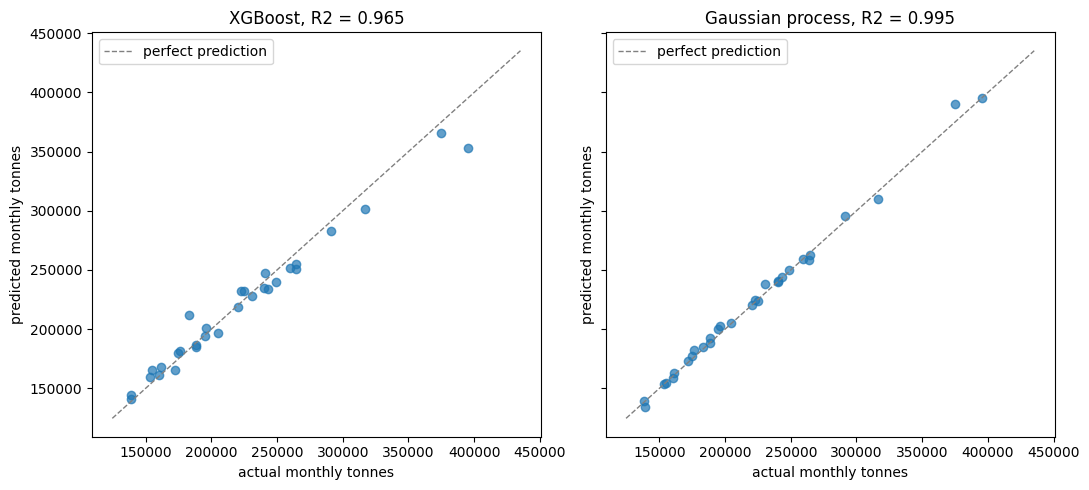

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
lims = [y_held_out.min() * 0.9, y_held_out.max() * 1.1]
for ax, name, held in zip(axes, ["XGBoost", "Gaussian process"], [xgb_held, gp_held]):
    ax.scatter(y_held_out, held["predictions"], alpha=0.7)
    ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, label="perfect prediction")
    ax.set_xlabel("actual monthly tonnes")
    ax.set_ylabel("predicted monthly tonnes")
    ax.set_title(f"{name}, R2 = {held['r2']:.3f}")
    ax.legend()
plt.tight_layout()
plt.show()

## Speed: the actual point of a surrogate

One simulation run against one surrogate prediction, and then the number that actually matters for Phase 4's optimisation search: predicting a few thousand points at once against how long that many simulation runs would take.

In [6]:
sample_params = X_train.iloc[0].to_dict()
sample_config = config_from_params(base_config, sample_params, horizon_days=90)

start = time.time()
run_simulation(sample_config, seed=1)
sim_time = time.time() - start

sample_row = X_train.iloc[[0]]

start = time.time()
xgb_model.predict(sample_row)
xgb_predict_time = time.time() - start

start = time.time()
gp_model.predict(sample_row)
gp_predict_time = time.time() - start

print(f"one 90 day simulation run:  {sim_time:.2f}s")
print(f"one XGBoost prediction:     {xgb_predict_time*1000:.2f}ms, {sim_time/xgb_predict_time:,.0f}x faster")
print(f"one GP prediction:          {gp_predict_time*1000:.2f}ms, {sim_time/gp_predict_time:,.0f}x faster")

n_batch = 5000
rng = np.random.default_rng(0)
batch = pd.DataFrame(rng.uniform(0, 1, size=(n_batch, len(FEATURE_COLS))), columns=FEATURE_COLS)
for col, (lo, hi) in PARAM_RANGES.items():
    batch[col] = lo + batch[col] * (hi - lo)

start = time.time()
xgb_model.predict(batch)
xgb_batch_time = time.time() - start

start = time.time()
gp_model.predict(batch)
gp_batch_time = time.time() - start

equivalent_hours = n_batch * sim_time / 3600
print()
print(f"predicting {n_batch:,} points, XGBoost: {xgb_batch_time:.2f}s, Gaussian process: {gp_batch_time:.2f}s")
print(f"the equivalent {n_batch:,} simulation runs, at {sim_time:.1f}s each, would take roughly {equivalent_hours:.1f} hours")

one 90 day simulation run:  3.21s
one XGBoost prediction:     1.49ms, 2,157x faster
one GP prediction:          1.51ms, 2,126x faster

predicting 5,000 points, XGBoost: 0.00s, Gaussian process: 0.06s
the equivalent 5,000 simulation runs, at 3.2s each, would take roughly 4.5 hours


## A full fidelity sanity check

The surrogate was trained on a cheaper 90 day proxy, to keep data generation to a few minutes. Before trusting it, this checks that the proxy actually tracks the real thing: 5 held out points, each run once at the full 365 day horizon with 20 replications, the same rigor Phase 1 and 2 used, compared against what the surrogate predicts for those same points.

In [7]:
sanity_points = held_out_df.sample(n=5, random_state=1)

rows = []
for idx, row in sanity_points.iterrows():
    params = row[FEATURE_COLS].to_dict()
    full_config = config_from_params(base_config, params, horizon_days=365)
    result = run_scenario(full_config, n_replications=20, base_seed=500)
    param_row = pd.DataFrame([params])
    rows.append(
        {
            "point": idx,
            "full_fidelity_true": result.mean_monthly_tonnes,
            "xgb_pred": xgb_model.predict(param_row)[0],
            "gp_pred": gp_model.predict(param_row)[0],
        }
    )

sanity_df = pd.DataFrame(rows).set_index("point")
sanity_df["xgb_pct_error"] = (sanity_df["xgb_pred"] - sanity_df["full_fidelity_true"]) / sanity_df["full_fidelity_true"] * 100
sanity_df["gp_pct_error"] = (sanity_df["gp_pred"] - sanity_df["full_fidelity_true"]) / sanity_df["full_fidelity_true"] * 100
sanity_df

,full_fidelity_true,xgb_pred,gp_pred,xgb_pct_error,gp_pct_error
point,,,,,
17,259380.802725,251654.531250,259353.338607,-2.978737,-0.010588
21,315468.613179,301651.312500,309914.005458,-4.379929,-1.760748
10,230692.988249,227945.500000,238138.397095,-1.190972,3.227410
19,243694.062811,233580.890625,244479.236927,-4.149946,0.322197
14,175557.410388,180154.203125,177297.927958,2.618399,0.991424


## Where the surrogate is, and is not, accurate

**Both models are trustworthy enough to use.** On the held out set, XGBoost's error is 5.3 percent of the mean monthly tonnes, the Gaussian process's is 2.0 percent, both a tight diagonal in the plot above, both a clear enough result to build Phase 4's optimisation search on.

**The Gaussian process won, and not for the reason I expected going in.** `phase3_plan.md` guessed that a tree based model would have the edge here, since the feed rate multiplier has a real kink in it below about 0.8, the system is feed constrained, above it the winder is the constraint and feed rate barely matters, and trees split on thresholds naturally. Checking that directly: near the kink, feed rate multiplier between 0.65 and 0.95, XGBoost's mean absolute error is 2.4 percent against the Gaussian process's 2.0 percent, close, roughly what a tree advantage on a threshold effect should look like. Away from the kink, XGBoost is at 4.1 percent against the Gaussian process's 1.0 percent, a much bigger gap. So the kink hypothesis was directionally right, XGBoost's relative disadvantage really is smaller right where the threshold sits, it just is not the dominant effect. Most of XGBoost's error comes from the smooth, well behaved regions of the input space, not the kink, and with only 200 points spread across five dimensions, a Gaussian process's built in assumption of smoothness lets it interpolate those regions more precisely than a shallow tree ensemble manages with the same amount of data. This is the textbook regime classical Kriging is known for, modest data, a handful of continuous inputs, which is a nice point of contact with the PhD work behind this project.

**The cheaper training horizon holds up.** Both models were trained only on 90 day runs, to keep data generation to a few minutes rather than hours. Checked against 5 points run at the real 365 day, 20 replication fidelity, XGBoost's error ranges from about 1 to 4 percent, the Gaussian process's from about 0 to 3 percent. The cheap proxy was a reasonable choice, not a shortcut that quietly broke the result.

**The actual point of doing this.** A single prediction from either model takes about 1.5 milliseconds against 2.7 seconds for one real simulation run, roughly 1,750 times faster. That difference does not matter much for one prediction, it matters enormously at scale: evaluating 5,000 candidate settings takes a fraction of a second here, the equivalent 5,000 simulation runs would take on the order of 3 to 4 hours. That gap is what makes Phase 4's search over thousands of settings practical at all.

## Saving both models

For Phase 4 to load directly rather than retraining. Saved under `data/processed/`, gitignored like the training data, but fully reproducible by rerunning this notebook.

In [8]:
from surrogate.train import save_model

save_model(xgb_model, str(PROJECT_ROOT / "data" / "processed" / "surrogate_xgboost.joblib"))
save_model(gp_model, str(PROJECT_ROOT / "data" / "processed" / "surrogate_gaussian_process.joblib"))
print("both models saved to data/processed/")

both models saved to data/processed/
